# Preparation

In [1]:
! pip install lbl-qubic

In [2]:
! git clone https://gitlab.com/LBL-QubiC/qubictutorial.git -b ipdps25
! pip install lbl-qubic-emulator
! pip install qutip
! pip install openpulse qiskit qiskit-qasm3-import pylatexenc
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


Cloning into 'qubictutorial'...
remote: Enumerating objects: 400, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 400 (delta 111), reused 0 (delta 0), pack-reused 198 (from 1)
Receiving objects: 100% (400/400), 22.03 MiB | 15.78 MiB/s, done.
Resolving deltas: 100% (213/213), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.

# Qubit control and readout

## Qubit drive and Rabi Oscillation



**Rabi oscillations** describe the coherent oscillation of a two-level quantum system (such as a qubit) between its ground state $\lvert 0\rangle$ and excited state $\lvert 1\rangle$ under the influence of a resonant driving field.

### Hamiltonian

The time-dependent Hamiltonian for a driven two-level system is:

$$
H(t) = \frac{\Omega}{2} \left( e^{i(\Delta\omega t + \phi)} \sigma_+ + e^{-i(\Delta\omega t + \phi)} \sigma_- \right)
$$

where:

- $\Omega$ is the Rabi frequency (proportional to the drive strength),
- $\Delta\omega$ is the detuning between the drive frequency and the qubit transition frequency,
- $\phi$ is the phase of the drive,
- $\sigma_+$ and $\sigma_-$ are the raising and lowering operators.

On resonance ($\Delta\omega = 0$), the Hamiltonian simplifies to:

$$
H = \frac{\Omega}{2} (\sigma_+ + \sigma_-) = \frac{\Omega}{2} \sigma_x
$$

### Rabi Oscillations

If the system starts in $\lvert 0\rangle$ and is driven resonantly, the probability of finding it in the excited state at time $t$ is:

$$
P_{|1\rangle}(t) = \sin^2\left(\frac{\Omega t}{2}\right)
$$

- A **$\pi$-pulse** ($t = \pi/\Omega$) inverts the population.
- A **$\pi/2$-pulse** ($t = \pi/(2\Omega)$) creates an equal superposition of $\lvert 0\rangle$ and $\lvert 1\rangle$.

### Experimental Relevance

By varying the pulse duration and measuring the excited state population, one observes oscillations known as **Rabi oscillations**. This is a fundamental method for characterizing and controlling two-level quantum systems in quantum information experiments.

In [3]:
import qutip as qt

# Parameters
T_rabi = 96e-9  # Pulse duration fixed at 96 ns
omega = 2 * np.pi / T_rabi  # Rabi frequency for 2pi at amplitude=1
pulse_length = 0.8*T_rabi
tlist = np.linspace(0, pulse_length, 200)

# Amplitude sweep: from 0 to 1.5 (arbitrary units)
amplitudes = np.linspace(0, 1.0, 101)

final_excited_pop = []
bloch_trajs = {}

for amp in amplitudes:
    sigma_plus = qt.sigmap()
    sigma_minus = qt.sigmam()
    delta_omega = 0.0e6
    phi = 0.0

    # Envelope is always 1 (square pulse), amplitude swept
    def H(t):
        return (amp * omega/2 * np.exp(1j*(delta_omega*t + phi)) * sigma_plus +
                amp * omega/2 * np.exp(-1j*(delta_omega*t + phi)) * sigma_minus)

    H_t = qt.QobjEvo(H)
    psi0 = qt.basis(2, 0)
    result = qt.mesolve(H_t, psi0, tlist, [], [], options=qt.Options(nsteps=1000))
    states = result.states

    pop_excited = qt.expect(qt.basis(2,1)*qt.basis(2,1).dag(), states[-1])
    final_excited_pop.append(pop_excited)



/usr/local/lib/python3.12/dist-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


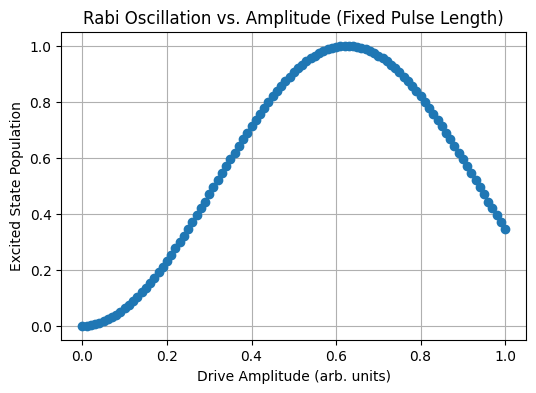

In [4]:
# Plot Rabi oscillation vs. amplitude
plt.figure(figsize=(6,4))
plt.plot(amplitudes, final_excited_pop, marker='o')
plt.xlabel('Drive Amplitude (arb. units)')
plt.ylabel('Excited State Population')
plt.title('Rabi Oscillation vs. Amplitude (Fixed Pulse Length)')
plt.grid(True)
plt.show()

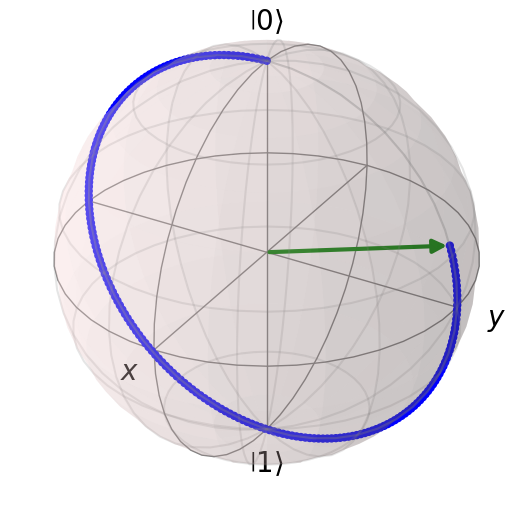

In [5]:
# Extract Bloch vector components
bloch_x = [qt.expect(qt.sigmax(), state) for state in states]
bloch_y = [qt.expect(qt.sigmay(), state) for state in states]
bloch_z = [qt.expect(qt.sigmaz(), state) for state in states]

# Plot on the Bloch sphere
b = qt.Bloch()
b.add_points([bloch_x, bloch_y, bloch_z])
b.add_vectors([ [bloch_x[-1], bloch_y[-1], bloch_z[-1]] ])  # Final state as a vector
b.make_sphere()
b.show()

## Readout: Lorentzian Resonance, Frequency and Time Domain

A **Lorentzian resonance** describes the response of a damped harmonic oscillator or a linear resonator (such as an LC circuit, optical cavity, or microwave resonator) to external driving.

---

### Frequency Domain

In the frequency domain, the response of a resonator to a continuous-wave (CW) drive at frequency $f$ is:

$$
H(f) = \frac{A}{1 + 2jQ \frac{f - f_0}{f_0}}
$$

where:
- $f_0$ is the resonance (center) frequency,
- $Q$ is the quality factor,
- $A$ is the amplitude scaling factor.

The **amplitude response** is a Lorentzian function:

$$
|H(f)| = \frac{A}{\sqrt{1 + 4Q^2 \left(\frac{f - f_0}{f_0}\right)^2}}
$$

- The response peaks at $f = f_0$.
- The **full width at half maximum (FWHM)** is $\Delta f = \frac{f_0}{Q}$.
- The Lorentzian lineshape is a hallmark of resonance phenomena.

---

### Time Domain

In the time domain, the resonator's response to a sudden excitation (like an impulse or a short pulse) is an exponentially decaying oscillation:

$$
h(t) = A\, e^{-\pi \Delta f\, t} \cos(2\pi f_0 t)\, \theta(t)
$$

or, equivalently, using the decay rate $\kappa$,

$$
h(t) = A\, e^{-\kappa t/2} \cos(2\pi f_0 t)\, \theta(t)
$$

where $\theta(t)$ is the Heaviside step function (zero for $t<0$, one for $t\geq 0$).

---

### Definition of $\kappa$, $\kappa_c$, and $\kappa_i$

The parameter $\kappa$ is the **total energy decay rate** (in radians per second):

$$
\kappa = \kappa_c + \kappa_i
$$

where:
- $\kappa_c$ is the **external (coupling) decay rate** (energy loss due to coupling to the environment or measurement port),
- $\kappa_i$ is the **internal decay rate** (energy loss due to intrinsic dissipation, such as dielectric, conductor, or radiative losses).

$\kappa$ also relates to the resonance frequency and quality factor:

$$
\kappa = 2\pi \Delta f = \frac{\omega_0}{Q} = \frac{2\pi f_0}{Q}
$$

where:
- $\Delta f = f_0/Q$ is the FWHM bandwidth,
- $\omega_0 = 2\pi f_0$ is the angular resonance frequency,
- $Q$ is the loaded quality factor (including both internal and coupling losses).

The **energy decay time (ringdown time constant)** is:

$$
\tau = \frac{1}{\kappa/2} = \frac{2Q}{\omega_0}
$$

---

### Physical Explanation

- In the **frequency domain**, the resonator "selects" frequencies near $f_0$, with a sharpness set by $Q$.
- In the **time domain**, energy stored in the resonator leaks out over time, leading to an exponentially decaying oscillation at $f_0$.
- The **relative sizes of $\kappa_c$ and $\kappa_i$** determine whether the resonator is undercoupled, overcoupled, or critically coupled.
    - If $\kappa_c \gg \kappa_i$: overcoupled (coupling dominates losses).
    - If $\kappa_c \ll \kappa_i$: undercoupled (internal losses dominate).
    - If $\kappa_c = \kappa_i$: critically coupled (maximum energy transfer to the port).
- The Fourier transform of the time-domain ringdown is the Lorentzian frequency response.

---

**In summary:**  
A Lorentzian resonance is a universal signature of damped, driven oscillators, with a sharp peak in frequency and a characteristic exponential decay in time. The decay rates $\kappa_c$ and $\kappa_i$ set the bandwidth and energy loss mechanisms, while their sum $\kappa$ determines the overall decay and lineshape.

In [6]:
# Resonator parameters
f0 = 6.7e9        # Resonance frequency [Hz]
Q = 1000          # Quality factor
fres=f0-1e6
kappa = 2 * np.pi * fres / Q
kappa_c = kappa / 2

# S11/S21
f = np.linspace(f0 - 20e6, f0 + 20e6, 1000)
omega = 2 * np.pi * f
omega0 = 2 * np.pi * f0
S11 = 1 - kappa_c / (1j*(omega - omega0) + kappa/2)
S21 = kappa_c / (1j*(omega - omega0) + kappa/2)

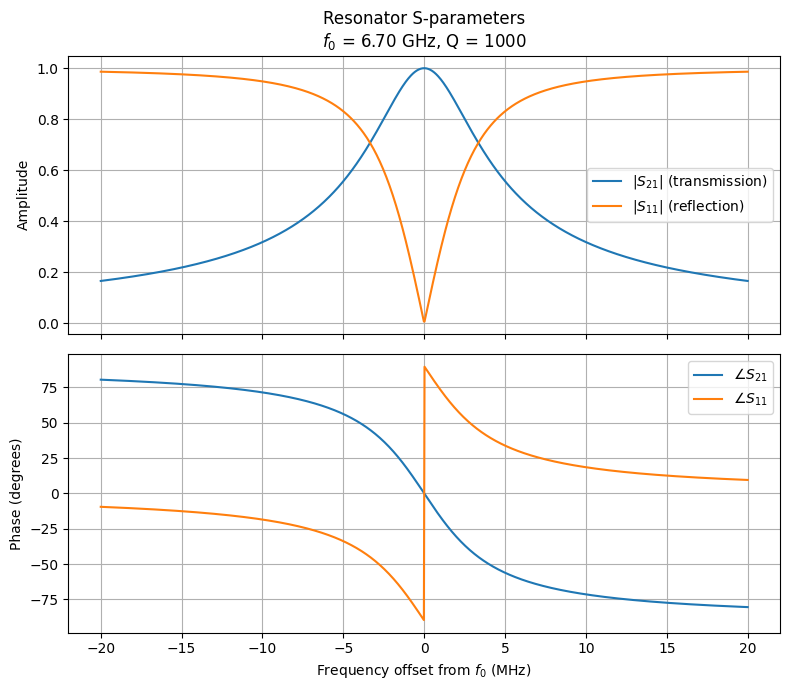

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,7), sharex=True)

ax1.plot((f-f0)/1e6, np.abs(S21), label=r'$|S_{21}|$ (transmission)')
ax1.plot((f-f0)/1e6, np.abs(S11), label=r'$|S_{11}|$ (reflection)')
ax1.set_ylabel('Amplitude')
ax1.set_title(f'Resonator S-parameters\n$f_0$ = {f0/1e9:.2f} GHz, Q = {Q}')
ax1.legend()
ax1.grid(True)

ax2.plot((f-f0)/1e6, np.angle(S21, deg=True), label=r'$\angle S_{21}$')
ax2.plot((f-f0)/1e6, np.angle(S11, deg=True), label=r'$\angle S_{11}$')
ax2.set_xlabel('Frequency offset from $f_0$ (MHz)')
ax2.set_ylabel('Phase (degrees)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# --- Time domain pulse parameters ---
pulse_length = 1e-6
t_max = 5e-6        # Total simulation time (s)
dt = 1e-9           # Time step (s)
t = np.arange(0, t_max, dt)

# Input pulse: always at f0
input_envelope = np.zeros_like(t)
input_envelope[t < pulse_length] = 1.0
input_pulse = input_envelope * np.exp(1j * 2 * np.pi * f0 * t)

# LO for mixing: always at f0
lo_cos = np.cos(2 * np.pi * f0 * t)
lo_sin = np.sin(2 * np.pi * f0 * t)

def simulate_resonator(fres):
    kappa = 2 * np.pi * fres / Q
    kappa_c = kappa / 2

    # Time-domain impulse response for S11
    impulse_response_S11 = np.zeros_like(t, dtype=complex)
    impulse_response_S11[0] = 1/dt  # Dirac delta
    impulse_response_S11 -= kappa_c * np.exp(-kappa * t / 2) * np.exp(1j * 2 * np.pi * fres * t)

    # Convolve and take real part (ADC)
    response = np.convolve(input_pulse, impulse_response_S11, mode='full')[:len(t)] * dt
    adc_response = np.real(response)

    # Mix to baseband using LO at f0
    I_mixed = adc_response * lo_cos
    Q_mixed = adc_response * lo_sin

    # Integrate I and Q over the whole time
    I_integrated = np.sum(I_mixed) * dt
    Q_integrated = np.sum(Q_mixed) * dt

    # Frequency response for S11
    f = np.linspace(f0 - 20e6, f0 + 20e6, 1000)
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * fres
    S11 = 1 - kappa_c / (1j*(omega - omega0) + kappa/2)

    return {
        'adc_response': adc_response,
        'I_mixed': I_mixed,
        'Q_mixed': Q_mixed,
        'I_integrated': I_integrated,
        'Q_integrated': Q_integrated,
        'S11': S11,
        'f': f
    }

# --- Simulate for both states ---
results_0 = simulate_resonator(f0 + 1e6)        # |0> state
results_1 = simulate_resonator(f0 - 1e6)  # |1> state


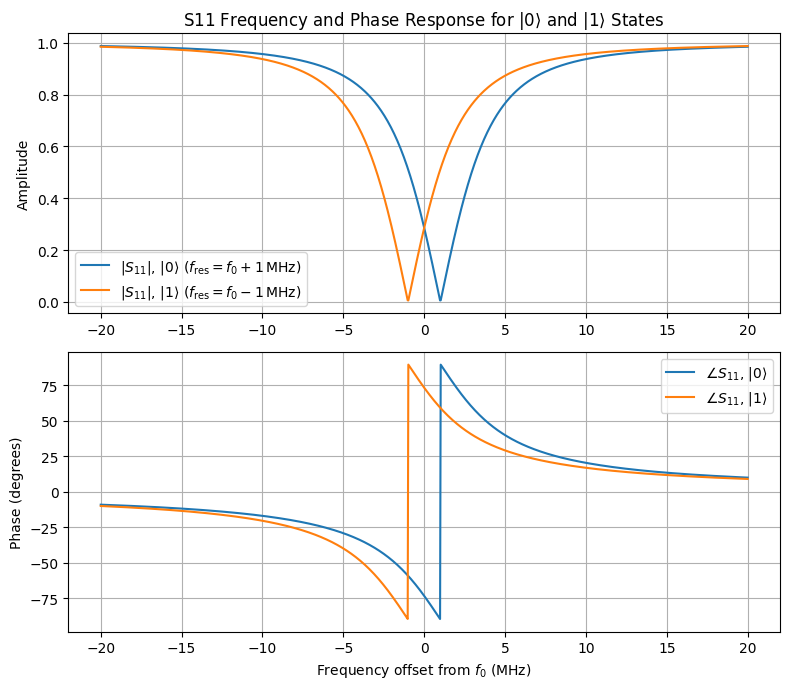

In [9]:
plt.figure(figsize=(8,7))

# Amplitude
plt.subplot(2,1,1)
plt.plot((results_0['f']-f0)/1e6, np.abs(results_0['S11']), label=r'$|S_{11}|$, $|0\rangle$ ($f_\mathrm{res}=f_0+1\,\mathrm{MHz}$)')
plt.plot((results_1['f']-f0)/1e6, np.abs(results_1['S11']), label=r'$|S_{11}|$, $|1\rangle$ ($f_\mathrm{res}=f_0-1\,\mathrm{MHz}$)')
plt.ylabel('Amplitude')
plt.title(r"S11 Frequency and Phase Response for $|0\rangle$ and $|1\rangle$ States")
plt.legend()
plt.grid(True)

# Phase
plt.subplot(2,1,2)
plt.plot((results_0['f']-f0)/1e6, np.angle(results_0['S11'], deg=True), label=r'$\angle S_{11}$, $|0\rangle$')
plt.plot((results_1['f']-f0)/1e6, np.angle(results_1['S11'], deg=True), label=r'$\angle S_{11}$, $|1\rangle$')
plt.xlabel('Frequency offset from $f_0$ (MHz)')
plt.ylabel('Phase (degrees)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

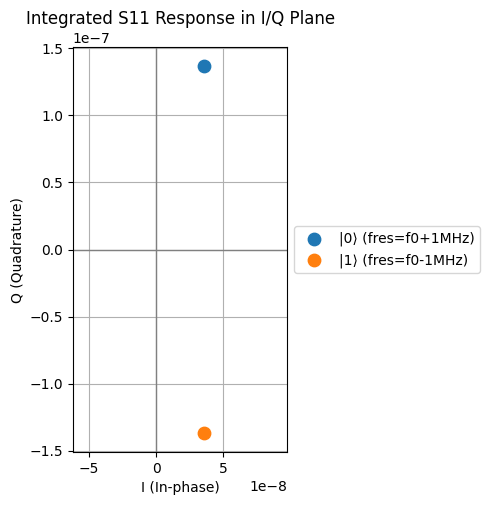

In [10]:
plt.figure(figsize=(5,5))
plt.scatter(results_0['I_integrated'], results_0['Q_integrated'], color='C0', s=80, label='|0⟩ (fres=f0+1MHz)')
plt.scatter(results_1['I_integrated'], results_1['Q_integrated'], color='C1', s=80, label='|1⟩ (fres=f0-1MHz)')
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.xlabel("I (In-phase)")
plt.ylabel("Q (Quadrature)")
plt.title("Integrated S11 Response in I/Q Plane")
plt.grid(True)
plt.axis('equal')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Legend outside right
plt.tight_layout()
plt.show()

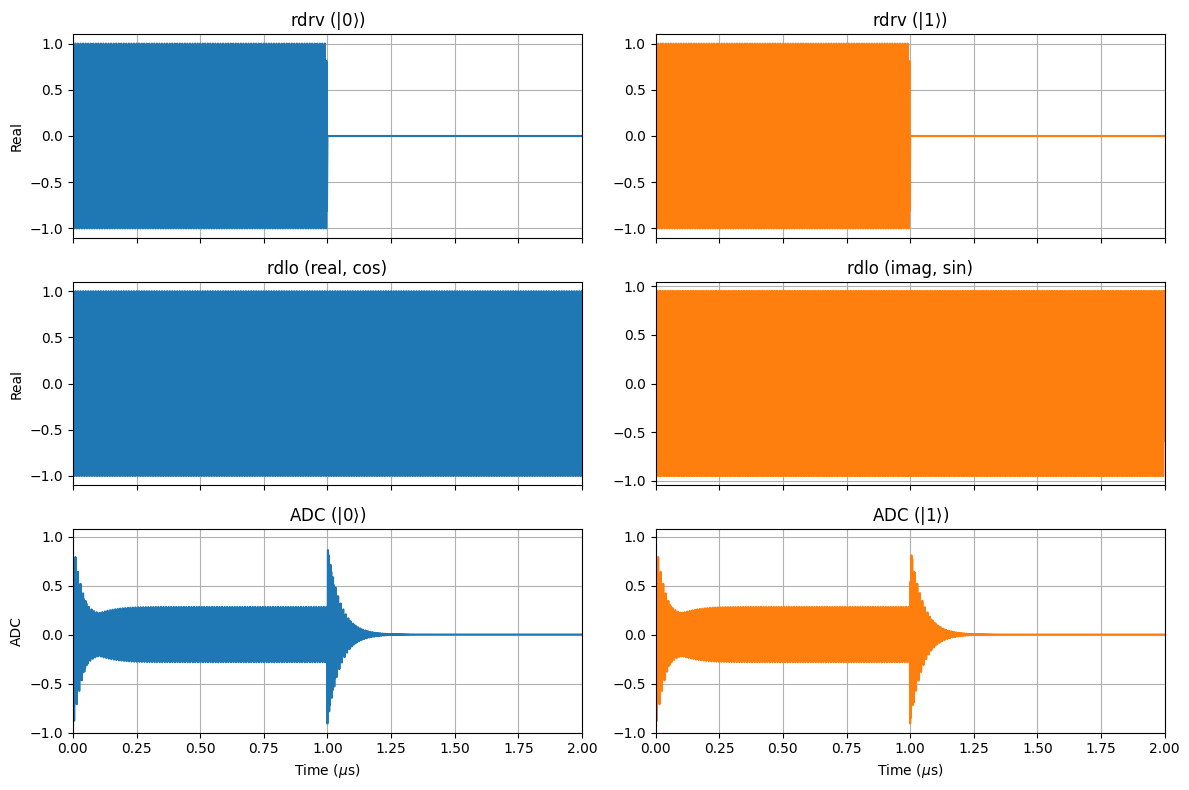

In [11]:
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

# Row 1: Input pulse (rdrv)
axs[0,0].plot(t*1e6, np.real(input_pulse), color='C0')
axs[0,0].set_title(r'rdrv ($|0\rangle$)')
axs[0,0].set_ylabel('Real')
axs[0,0].grid(True)
axs[0,0].set_xlim(0, 2)

axs[0,1].plot(t*1e6, np.real(input_pulse), color='C1')
axs[0,1].set_title(r'rdrv ($|1\rangle$)')
axs[0,1].grid(True)
axs[0,1].set_xlim(0, 2)

# Row 2: LO (rdlo)
axs[1,0].plot(t*1e6, lo_cos, color='C0')
axs[1,0].set_title(r'rdlo (real, cos)')
axs[1,0].set_ylabel('Real')
axs[1,0].grid(True)
axs[1,0].set_xlim(0, 2)

axs[1,1].plot(t*1e6, lo_sin, color='C1')
axs[1,1].set_title(r'rdlo (imag, sin)')
axs[1,1].grid(True)
axs[1,1].set_xlim(0, 2)

# Row 3: ADC response (real part)
axs[2,0].plot(t*1e6, results_0['adc_response'], color='C0')
axs[2,0].set_title(r'ADC ($|0\rangle$)')
axs[2,0].set_xlabel(r'Time ($\mu$s)')
axs[2,0].set_ylabel('ADC')
axs[2,0].grid(True)
axs[2,0].set_xlim(0, 2)

axs[2,1].plot(t*1e6, results_1['adc_response'], color='C1')
axs[2,1].set_title(r'ADC ($|1\rangle$)')
axs[2,1].set_xlabel(r'Time ($\mu$s)')
axs[2,1].grid(True)
axs[2,1].set_xlim(0, 2)

plt.tight_layout()
plt.show()

# Pulse and Gate

## Parametric Waveforms in Quantum Control

In QubiC, control pulses are generated in a **parametric** way, meaning that their properties are described by a set of parameters, not by uploading fixed arrays.

---

### Pulse Structure

A typical control pulse is **amplitude modulated** and can be described as:

$$
s(t) = \text{Envelope}(t) \cdot \cos(2\pi f_\text{carrier} t + \phi_0)
$$

or, in complex notation (for I/Q modulation):

$$
s(t) = \text{Envelope}(t) \cdot e^{i(2\pi f_\text{carrier} t + \phi_0)}
$$

- **Envelope(t):** Describes the shape of the pulse in time (e.g., square, Gaussian, DRAG).
    - **Parameters:** pulse length (duration,width), amplitude, shape parameters (like $\alpha$, $\sigma$, etc.)
- **Carrier:** A microwave-frequency oscillation defined by:
    - $f_\text{carrier}$: The carrier frequency (sets qubit transition)
    - $\phi_0$: The initial phase

---

### Example: DRAG Pulse

A commonly used envelope is the **DRAG** (Derivative Removal by Adiabatic Gate) pulse, which is a shaped Gaussian pulse with a derivative component to reduce leakage.

- The envelope is generated by a function (e.g., `DRAG`) with parameters such as:
    - **Amplitude**
    - **Duration**
    - **Alpha, sigma, delta** (shape parameters)
      
---


### QubiC configration

In [12]:
cd qubictutorial/

/content/qubictutorial


In [13]:
import distproc.hwconfig as hwconfig
import distproc.compiler as compiler
import qubic.toolchain as toolchain
import qubitconfig.qchip as qchip

fpga_config = hwconfig.FPGAConfig()
channel_configs = hwconfig.load_channel_configs('./config/channel_config.json')

In [14]:
from emulator.emulator import Emulator

Emulator.generate_hwcfg("./config/hw_config.json", channel_configs, "./config/dsp_config.yaml",fpga_config)
Emulator.generate_qubitcfg("./config/em_qubit_config.json", "./config/qubitcfg.json")

em = Emulator(chanconfig_path='./config/channel_config.json', hwconfig_path='./config/hw_config.json', qubitconfig_path='./config/em_qubit_config.json')

/usr/local/lib/python3.12/dist-packages/emulator/hardware/distributed_processor.py:163: UserWarning: Q7 configuration is not included in qubit config.Default values are being used
  warnings.warn(f"{name} configuration is not included in qubit config."
/usr/local/lib/python3.12/dist-packages/emulator/hardware/distributed_processor.py:163: UserWarning: Q6 configuration is not included in qubit config.Default values are being used
  warnings.warn(f"{name} configuration is not included in qubit config."
/usr/local/lib/python3.12/dist-packages/emulator/hardware/distributed_processor.py:163: UserWarning: Q5 configuration is not included in qubit config.Default values are being used
  warnings.warn(f"{name} configuration is not included in qubit config."
/usr/local/lib/python3.12/dist-packages/emulator/hardware/distributed_processor.py:163: UserWarning: Q4 configuration is not included in qubit config.Default values are being used
  warnings.warn(f"{name} configuration is not included in qub

## Pulse level programming

### Single pulse

In [15]:
circuit = [
    #play a single pulse on the Q0 drive channel
    {'name':'pulse','phase':0,'freq':2.9e8,'amp':1,'twidth':32e-9,
#     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'env':{'env_func':'DRAG','paradict':{'alpha':0.0,'sigmas':3}},
     'dest':'Q0.qdrv'}
]

In [16]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None,
                                            compiler_flags=compiler.CompilerFlags(resolve_gates=False),
                                            qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo')
)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

In [17]:
em.load_program(asm_prog)
result = em.execute()

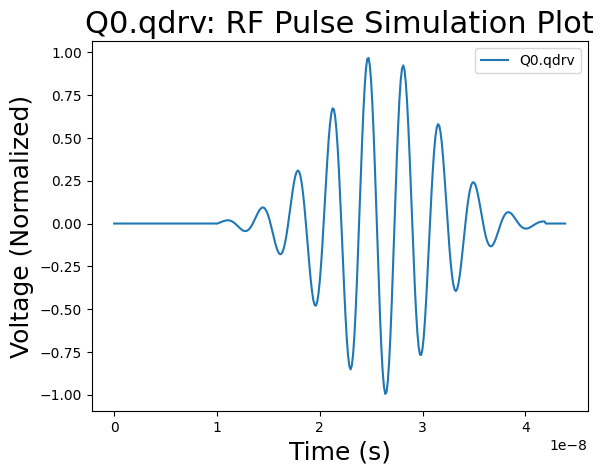

In [18]:
result.graph_channel('Q0.qdrv')

Multiple pulses on the same channel are played **sequentially**.



### Two consecutive pulses on the same channel played **sequentially**

In [19]:
circuit = [
    #play two pulses on the Q0 drive channel
    {'name': 'pulse', 'phase': 0, 'freq': 4e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'pulse', 'phase': 0, 'freq': 2e8, 'amp': 0.6, 'twidth': 3.6e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'}

]

In [20]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

In [21]:
em.load_program(asm_prog)
result = em.execute()

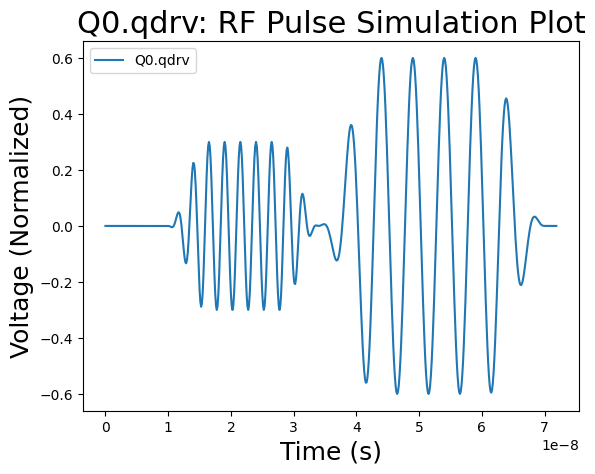

In [22]:
result.graph_channel('Q0.qdrv')

### Pulses on separate channels are scheduled in **parallel**
Pulse is played as soon as it's output channel is available.

In [23]:
circuit = [
    # play two pulses on the Q0 drive channel
    {'name': 'pulse', 'phase': 0, 'freq': 4e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'pulse', 'phase': 0, 'freq': 4e8, 'amp': 0.6, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    # add a single pulse on Q1 drive -- this will be scheduled immediately, and played in parallel with the first Q0 pulse
    {'name': 'pulse', 'phase': 0, 'freq': 2e8, 'amp': 0.6, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q1.qdrv'}

]

In [24]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

In [25]:
em.load_program(asm_prog)
result = em.execute()

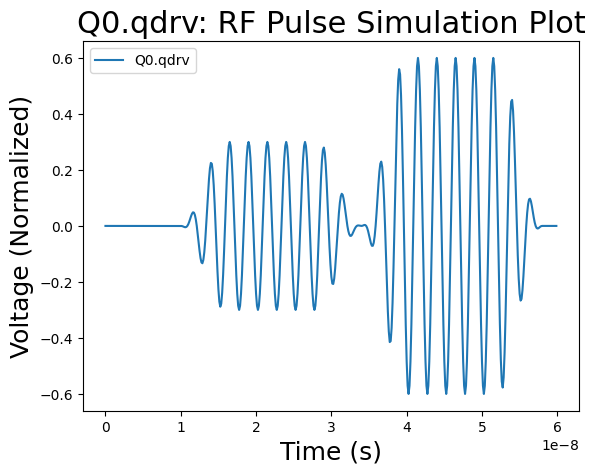

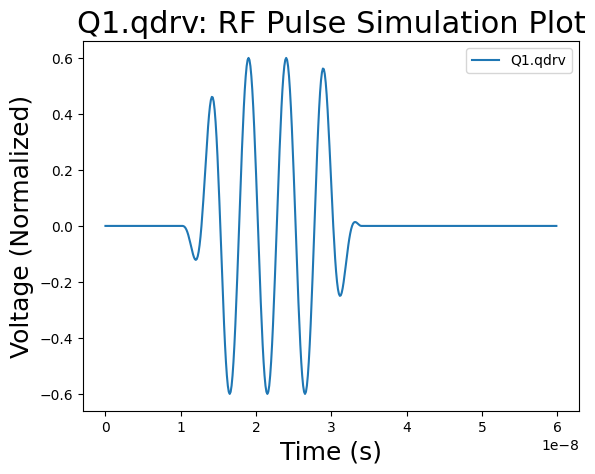

In [26]:
result.graph_channel('Q0.qdrv')
result.graph_channel('Q1.qdrv')

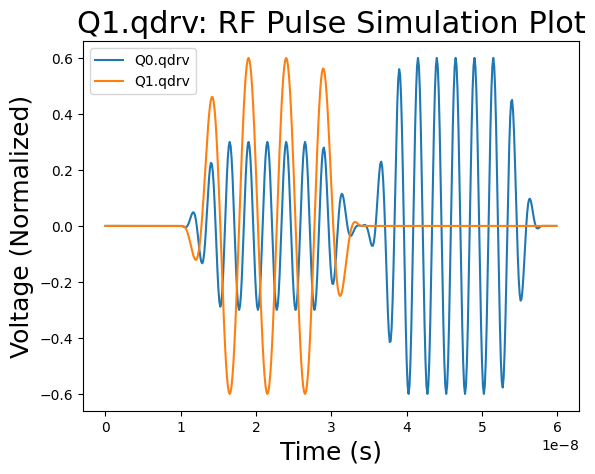

In [27]:
result.graph_multiple_channels(['Q0.qdrv', 'Q1.qdrv'])

### Timing Constraints

Delays and barriers can be used to control when pulses are played relative to one another:
  - `delay`: delay subsequent pulses on all channels in `scope` by amount `t` (in seconds). If `scope` is not provided, delay all channels
  - `barrier`: insert a scheduling barrier that applies to all channels in `scope`. All subsequent pulses on those channels are scheduled to play after the last pulse before the barrier (on those same channels) has finished (this is very similar to the behavior of a barrier in Qiskit). As with the `delay` instruction, if no channels are provided in `scope`, the barrier is applied to all channels.


In [28]:
circuit = [
    #play two pulses on the Q0 drive channel
    {'name': 'pulse', 'phase': 0, 'freq': 4944383311, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'delay', 't': 50.e-9},

    {'name': 'pulse', 'phase': 0, 'freq': 4944383311, 'amp': 0.6, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'barrier'},

    {'name': 'pulse', 'phase': 0, 'freq': 4944383311, 'amp': 0.6, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q1.qdrv'}

]

Compile, run, and plot the output below:

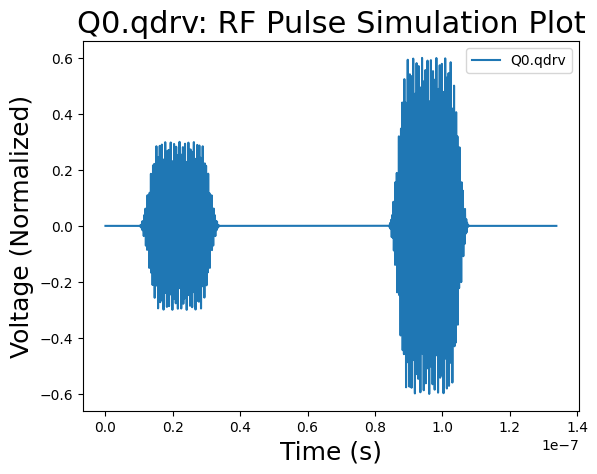

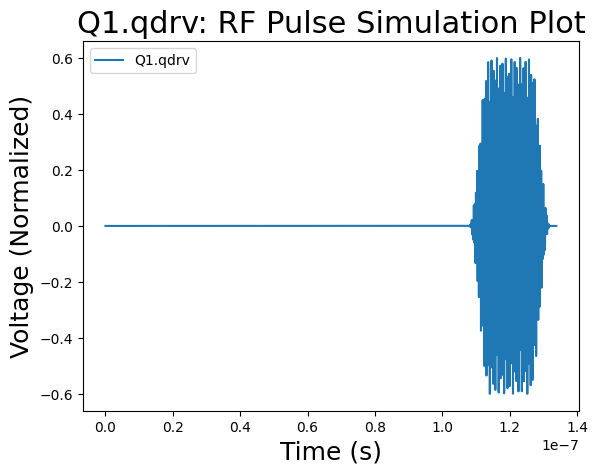

In [29]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False},
                                           qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo')
                                            )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute()
result.graph_channel('Q0.qdrv')
result.graph_channel('Q1.qdrv')

### Scoped Delays and Barriers

Delays and barriers can be scoped to a subset of channels using the `scope` field (e.g. `{'name': 'barrier', 'scope': ['Q0', 'Q2']}`).

In [30]:
# add barriers to the circuit below:

circuit = [
    {'name': 'pulse', 'phase': 0, 'freq': 1e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'pulse', 'phase': 0, 'freq': 3e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q2.qdrv'},

    {'name': 'pulse', 'phase': 0, 'freq': 1e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.qdrv'},

    {'name': 'barrier', 'scope': ['Q0', 'Q2']},

    {'name': 'pulse', 'phase': 0, 'freq': 2e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q1.qdrv'},

    {'name': 'pulse', 'phase': 0, 'freq': 3e8, 'amp': 0.3, 'twidth': 2.4e-08,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q2.qdrv'},

]

In [31]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

em.load_program(asm_prog)
result = em.execute()

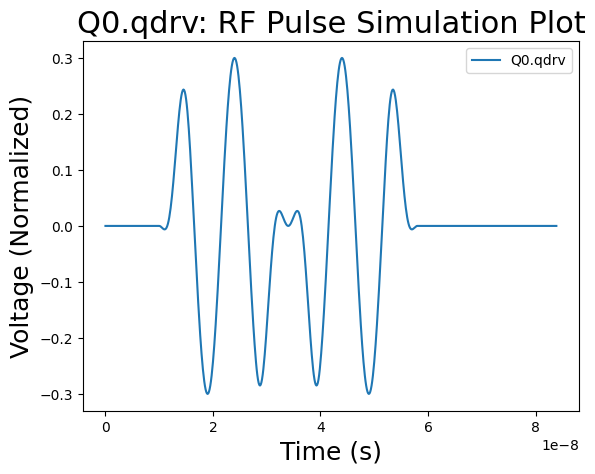

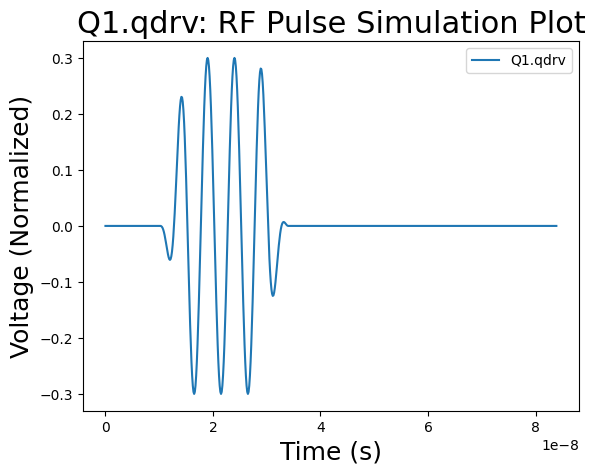

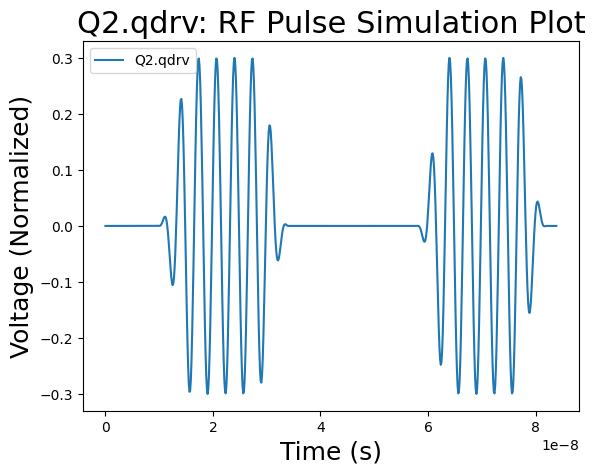

In [32]:
result.graph_channel('Q0.qdrv')
result.graph_channel('Q1.qdrv')
result.graph_channel('Q2.qdrv')


### Readout pulse

#### Single readout pulse

In [33]:
circuit = [
    {'name': 'pulse', 'phase': 0, 'freq': 6.1e9, 'amp': 0.6, 'twidth': 1e-07,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.rdrv'}
    ]

In [34]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

em.load_program(asm_prog)
result = em.execute()

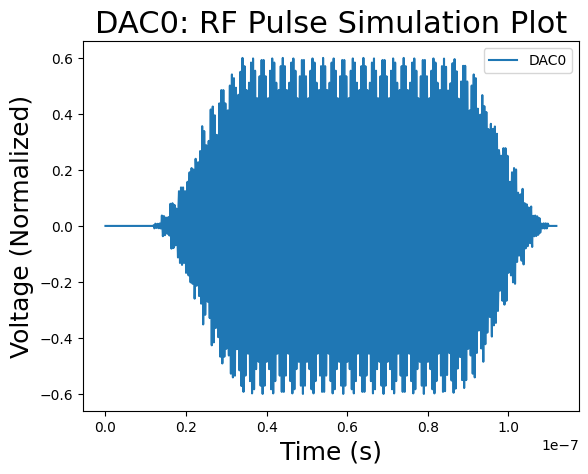

In [35]:
result.graph_dac('DAC0')

#### Frequency multiplexed readout pulse

In [36]:
circuit = [{'name': 'pulse', 'phase': 0, 'freq': 6.1e9, 'amp': 0.4, 'twidth': 1e-06,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q0.rdrv'},
           {'name': 'pulse', 'phase': 0, 'freq': 6.15e9, 'amp': 0.4, 'twidth': 1e-06,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q1.rdrv'},
           {'name': 'pulse', 'phase': 0, 'freq': 6.35e9, 'amp': 0.4, 'twidth': 1e-06,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q2.rdrv'}
           ]

In [37]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

em.load_program(asm_prog)
result = em.execute()

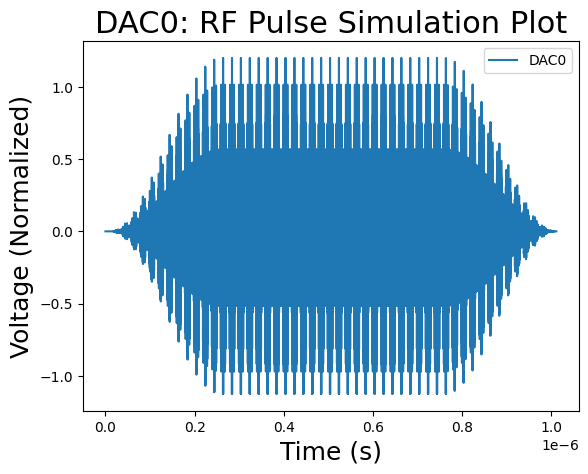

In [38]:
result.graph_dac('DAC0')

Text(0.5, 0, 'freq (Hz)')

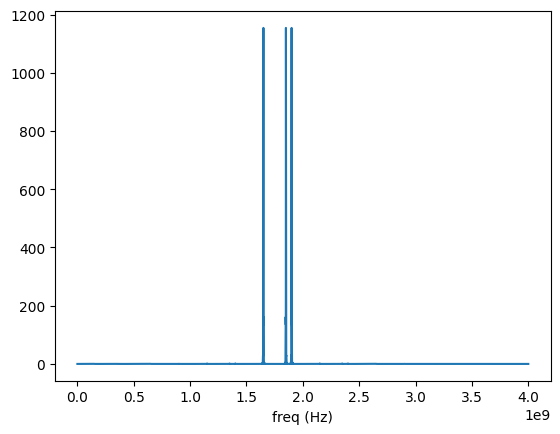

In [39]:
# If we plot an FFT of the above signal we can see both frequency components:
rdrv_dac_data = result.get_dac_data('DAC0')['voltage']
fftfreq = np.fft.rfftfreq(len(rdrv_dac_data), 1/8e9)
rdrv_fft = np.fft.rfft(rdrv_dac_data)
plt.plot(fftfreq, np.abs(rdrv_fft))
plt.xlabel('freq (Hz)')

In [40]:
### Readout digital local oscillator

In [41]:
circuit = [
    {'name': 'pulse', 'phase': 0, 'freq': 6.55e9, 'amp': 1, 'twidth': 1e-6,
                'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.15}},
                'dest': 'Q0.rdrv'},
    {'name': 'pulse', 'phase': 0, 'freq': 6.15e9, 'amp': 0.4, 'twidth': 1e-06,
     'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
     'dest': 'Q1.rdrv'},
    {'name': 'pulse', 'phase': 0, 'freq': 6.55e9, 'amp': 1, 'twidth': 1e-6,
                'env': {'env_func': 'square', 'paradict': {}},
                'phase': np.pi/2, 'dest': 'Q0.rdlo'}
    ]

In [42]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, None, compiler_flags={'resolve_gates': False})
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

em.load_program(asm_prog)
#result = em.execute()
result = em.execute(toggle_resonator=True, toggle_qubits=True)


/usr/local/lib/python3.12/dist-packages/emulator/hardware/distributed_processor.py:445: UserWarning: RDLO signal needed for proper IQ Mixing, array of sample points is empty
  warnings.warn(f"RDLO signal needed for proper IQ Mixing, {e}")


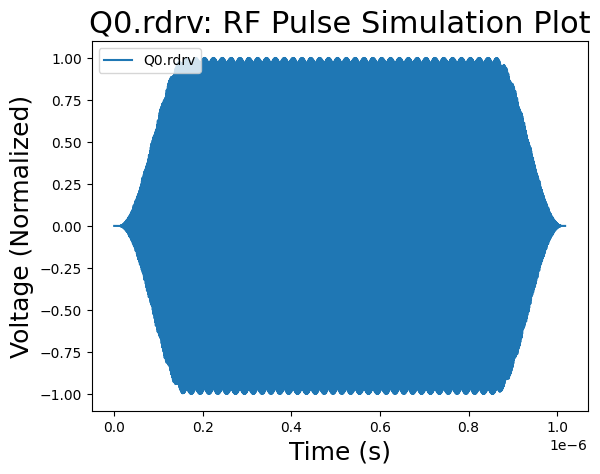

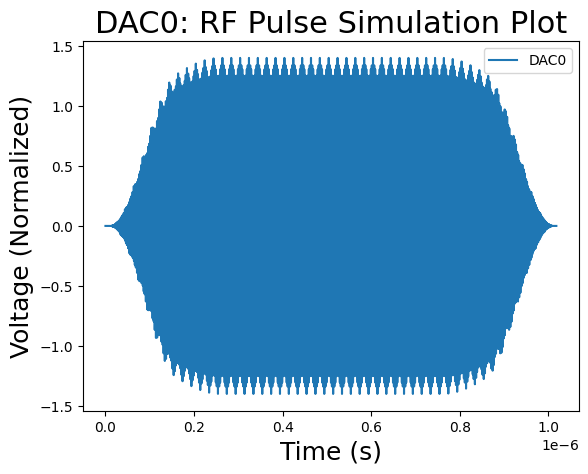

In [43]:
result.graph_channel('Q0.rdrv')
result.graph_dac('DAC0') # rdrv channels belong to 0th dac

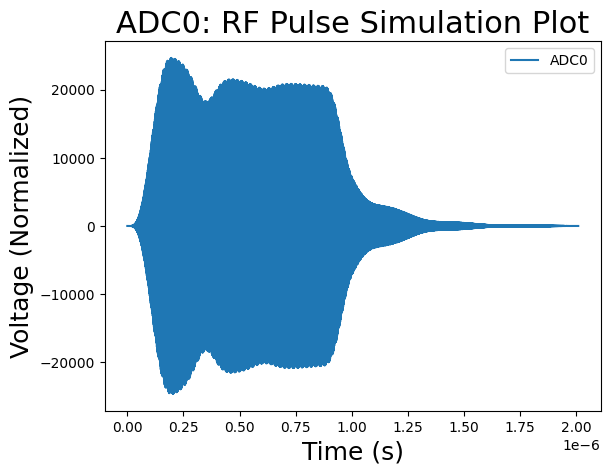

In [44]:
result.graph_adc('ADC0')

#### Accumulated buffer

In [45]:
result.iq_values


array([-341853.88203265-140001.86253216j,
             0.             +0.j        ])

## Gate level programming


### Gate (calibrated or not) configuration from qubitcfg.json

In [46]:
qubitcfg = qchip.QChip('./config/qubitcfg.json')

In [47]:
qubitcfg.gates.keys()

dict_keys(['M0mark', 'alignmentread', 'vnaread', 'Q0X90', 'Q0X90_ef', 'Q0rabi_ef', 'Q0rabi', 'Q0read', 'Q1X90', 'Q1X90_ef', 'Q1rabi_ef', 'Q1rabi', 'Q1read', 'Q2X90', 'Q2X90_ef', 'Q2rabi_ef', 'Q2rabi', 'Q2read', 'Q3X90', 'Q3X90_ef', 'Q3rabi_ef', 'Q3rabi', 'Q3read', 'Q5X90', 'Q5X90_ef', 'Q5rabi_ef', 'Q5rabi', 'Q5read', 'Q4X90_ef', 'Q4X90', 'Q4rabi_ef', 'Q4rabi', 'Q4read', 'Q6X90', 'Q6X90_ef', 'Q6rabi_ef', 'Q6rabi', 'Q6read', 'Q7X90', 'Q7X90_ef', 'Q7rabi_ef', 'Q7rabi', 'Q7read', 'Q5Q4CR', 'Q5Q4CNOT', 'Q3Q6CR', 'Q3Q6CNOT', 'Q0Z90', 'Q1Z90', 'Q2Z90', 'Q3Z90', 'Q0Y-90', 'Q1Y-90', 'Q2Y-90', 'Q3Y-90', 'Q7Y-90', 'Q5Y-90', 'Q4Y-90', 'Q2Q1CR', 'Q2Q1CNOT', 'Q6Q5CR', 'Q6Q5CNOT', 'Q6Y-90', 'Q4Q3CR', 'Q4Q3CNOT', 'Q3Q2CR', 'Q3Q2CNOT', 'Q0Q1CZ', 'Q2Q3CZ', 'Q1Q2CZ', 'Q3Q4CZ', 'Q4Q5CZ', 'Q5Q6CZ', 'Q6Q7CZ'])

In [48]:
qubitcfg.gates['Q0X90'].cfg_dict

[{'freq': 'Q0.freq',
  'phase': 0.0,
  'dest': 'Q0.qdrv',
  'twidth': 2.4e-08,
  't0': 0.0,
  'amp': 0.1,
  'env': [{'env_func': 'cos_edge_square',
    'paradict': {'ramp_fraction': 0.25}}]}]

In [49]:
qubitcfg.gates['Q0Q1CZ'].cfg_dict

[{'freq': 5365000000.0,
  'phase': 0.0,
  'dest': 'Q0.qdrv',
  'twidth': 4e-07,
  't0': 0,
  'amp': 0.27513,
  'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}}},
 {'freq': 5365000000.0,
  'phase': -3.34039,
  'dest': 'Q1.qdrv',
  'twidth': 4e-07,
  't0': 0,
  'amp': 0.27513,
  'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}}},
 {'gate': 'virtualz', 'freq': 'Q0.freq', 'phase': -2.54665},
 {'gate': 'virtualz', 'freq': 'Q1.freq', 'phase': 1.17176}]

In [50]:
qubitcfg.gates['Q0read'].cfg_dict

[{'freq': 'Q0.readfreq',
  'phase': 0.0,
  'dest': 'Q0.rdrv',
  'twidth': 1e-06,
  't0': 0.0,
  'amp': 1,
  'env': [{'env_func': 'cos_edge_square',
    'paradict': {'ramp_fraction': 0.15, 'twidth': 1e-06}}]},
 {'freq': 'Q0.readfreq',
  'phase': 'np.pi/2',
  'dest': 'Q0.rdlo',
  'twidth': 1e-06,
  't0': 0,
  'amp': 1.0,
  'env': [{'env_func': 'square',
    'paradict': {'phase': 0.0, 'amplitude': 1.0, 'twidth': 1e-06}}]}]

### Compose circuit using gates

In [51]:
circuit = [
    # {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q2'},
#    {'name': 'X90', 'qubit': 'Q1'},
    {'name': 'CNOT', 'qubit': ['Q2','Q1']},
#    {'name': 'CZ', 'qubit': ['Q0','Q1']}
]

In [52]:
# link the qchip configuration at compile time
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
#compiled_prog.program

In [53]:
em.load_program(asm_prog)
result = em.execute()

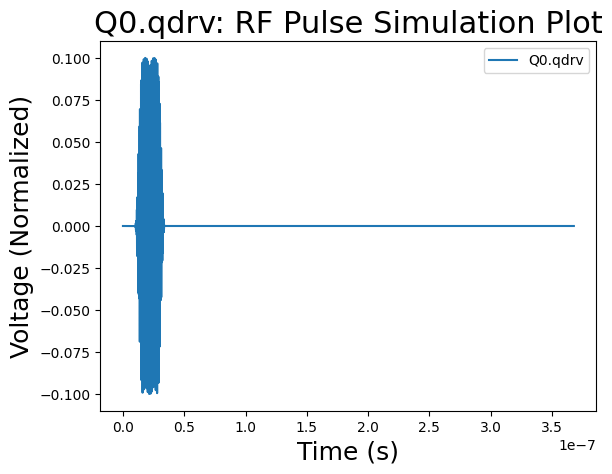

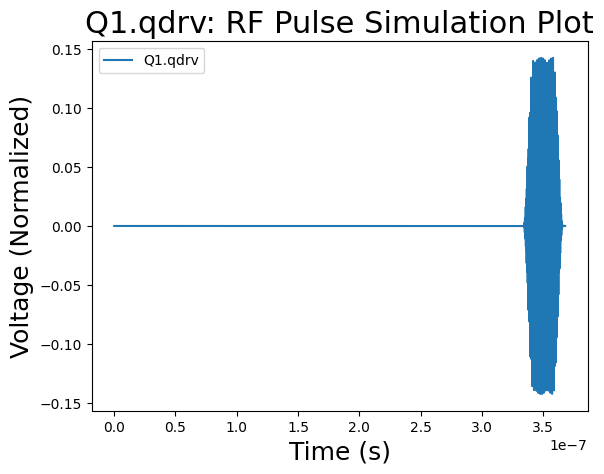

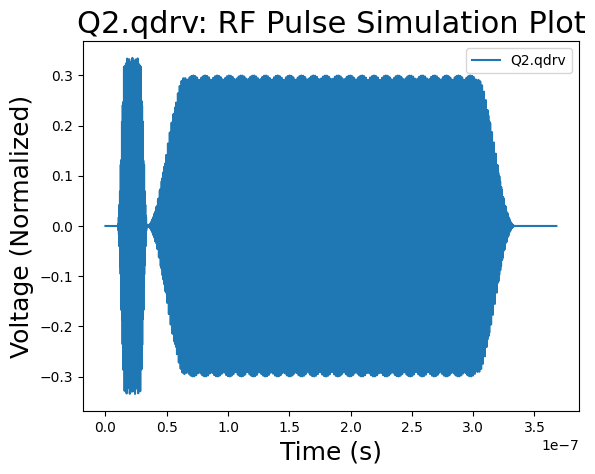

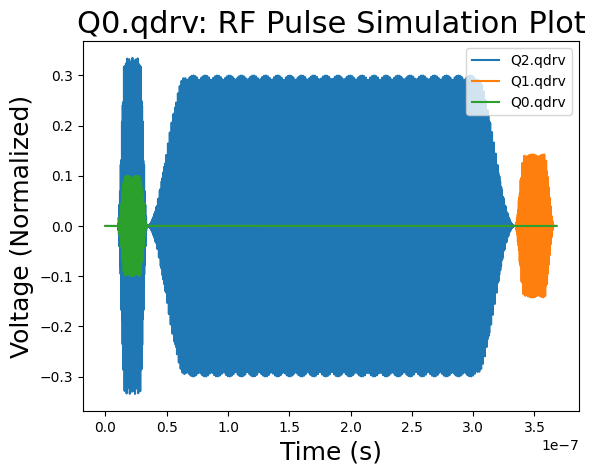

In [54]:
result.graph_channel('Q0.qdrv')
result.graph_channel('Q1.qdrv')
result.graph_channel('Q2.qdrv')
result.graph_multiple_channels(['Q2.qdrv', 'Q1.qdrv','Q0.qdrv'])

In [55]:
# Simulate with Qutip
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True)

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


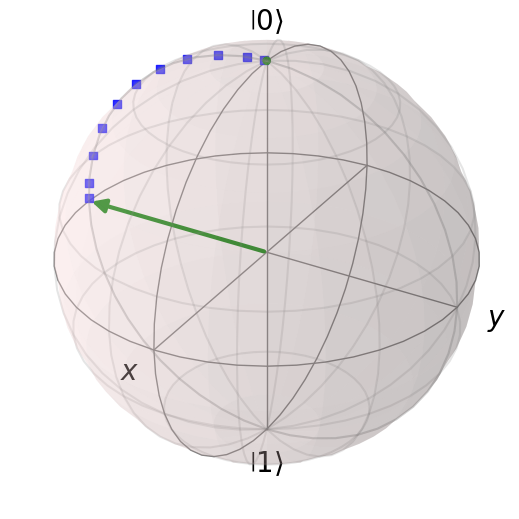

In [56]:
result.graph_bloch('Q0')

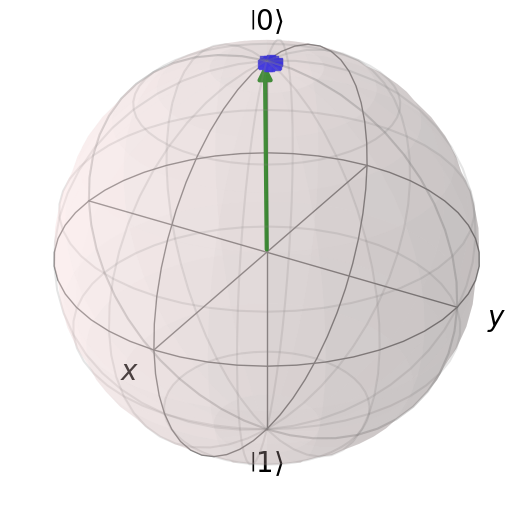

In [57]:
result.graph_bloch('Q1')

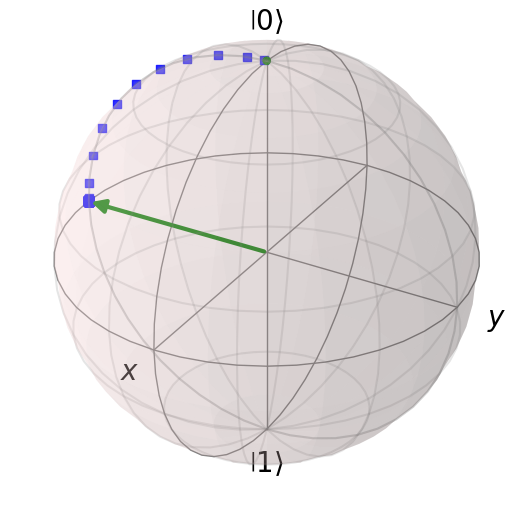

In [58]:
result.graph_bloch('Q2')

### Virtual Z gate

#### By modify gate

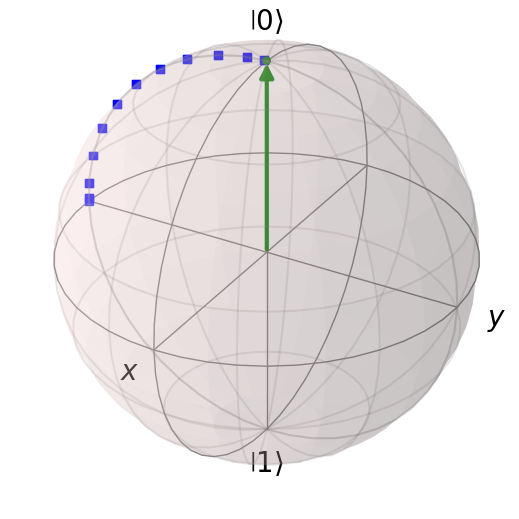

In [59]:
# Modifying the relative phase of the second pulse
circuit = [
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q0','modi':{(0, 'phase'): 12*np.pi/12}},
]
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True)
result.graph_bloch('Q0')

#### By virtual Z gate

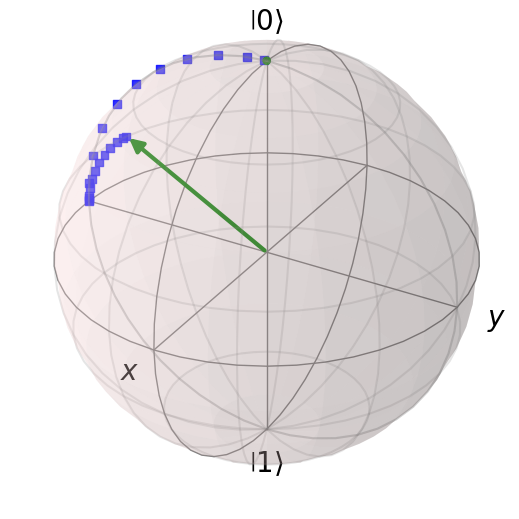

In [60]:
# try modifying the relative phase of the second pulse
circuit = [
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'virtual_z', 'qubit': 'Q0', 'phase': 7*np.pi/12},
    {'name': 'X90', 'qubit': 'Q0'}
]
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True)
result.graph_bloch('Q0')



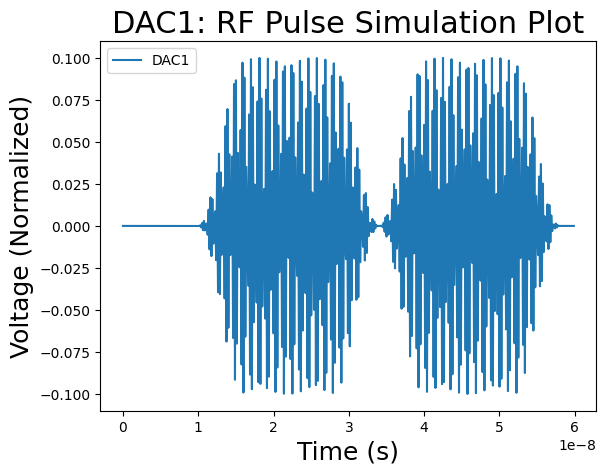

In [61]:
result.graph_dac('DAC1')

### Readout "gate"

In [62]:
circuit = [
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'read', 'qubit': 'Q0'}
    ]

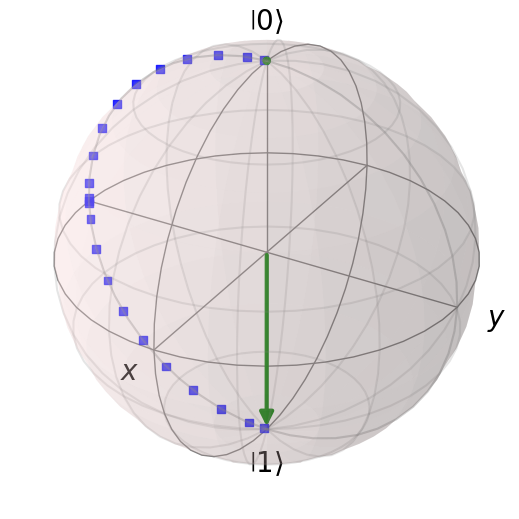

In [63]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True)
result.graph_bloch('Q0')

### Readout state discrimination

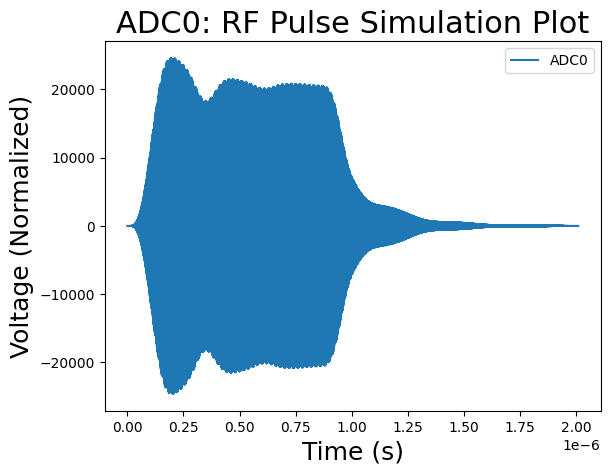

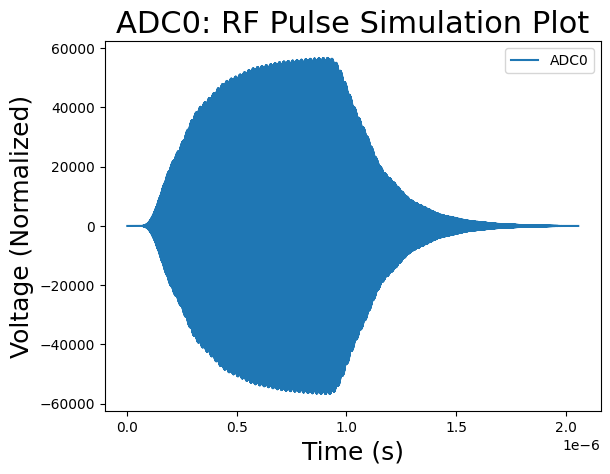

In [64]:
circuit = [
    {'name': 'read', 'qubit': 'Q0'}
    ]
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True,toggle_resonator=True)
result.graph_adc('ADC0')
zero_iq = result.iq_values

circuit = [
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'read', 'qubit': 'Q0'}
    ]
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                      qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo') )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute(toggle_qubits=True,toggle_resonator=True)
result.graph_adc('ADC0')
one_iq = result.iq_values

Text(0, 0.5, 'Q')

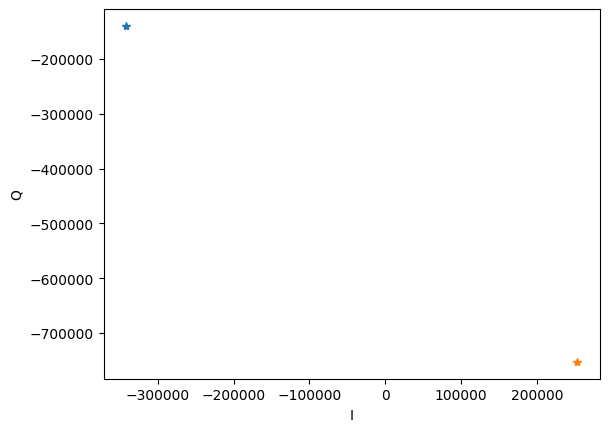

In [65]:
plt.plot(zero_iq.real, zero_iq.imag, '*', label='zero')
plt.plot(one_iq.real, one_iq.imag, '*', label='one')
plt.xlabel('I')
plt.ylabel('Q')

## OpenQASM to qubic

### Import modules

In [66]:
import qiskit
import qiskit.qasm3 as qasm3
import pprint

In [67]:
# load QubiC OpenQASM3 support
import distproc.openqasm as qubicqasm

### Simplest circuit

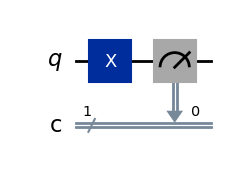

In [68]:
qiskit_circuit=qiskit.QuantumCircuit(1,1)
qiskit_circuit.x(0)
qiskit_circuit.measure(0,0)
qiskit_circuit.draw('mpl')

In [69]:
# convert the generated OpenQASM program to a QubiC progpram
circuit = qubicqasm.load_qasm(qasm3.dumps(qiskit_circuit),
                              qubitcfg,options={'barrier': 'none',})
pprint.pprint(circuit)

[{'name': 'declare', 'scope': {'Q0'}, 'var': 'c_0'},
 {'name': 'delay', 't': 0.0005},
 {'name': 'barrier'},
 {'name': 'virtual_z', 'phase': -1.5707963267948966, 'qubit': ['Q0']},
 {'name': 'X90', 'qubit': ['Q0']},
 {'name': 'virtual_z', 'phase': 0.0, 'qubit': ['Q0']},
 {'name': 'X90', 'qubit': ['Q0']},
 {'name': 'virtual_z', 'phase': -1.5707963267948966, 'qubit': ['Q0']},
 {'name': 'read', 'qubit': 'Q0'}]


In [70]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                     qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo')
                                     )
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
#result = em.execute()
result = em.execute(toggle_resonator=True, toggle_qubits=True)


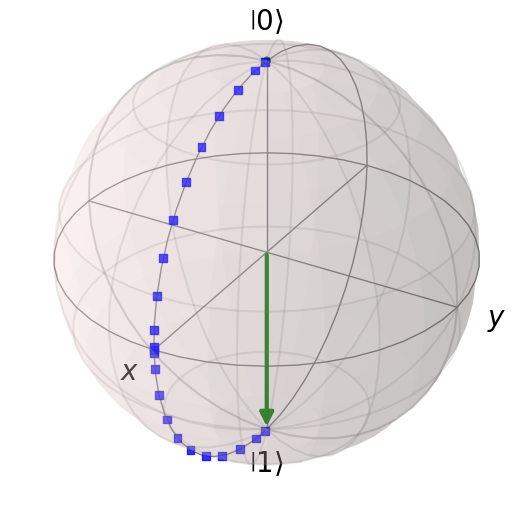

In [71]:
result.graph_bloch('Q0')

### Include 2 qubit gate

In [72]:
# Create a Quantum Circuit acting on a quantum register of two qubits and measurement
circuit = qiskit.QuantumCircuit(2,2)
# Add a H gate on qubit $q_{0}$, putting this qubit in superposition.
circuit.h(0)
# Add a CX (CNOT) gate on control qubit $q_{0}$ and target qubit $q_{1}$, putting
# the qubits in a Bell state.
circuit.cx(0, 1)
#Add a barrier before measurement
circuit.barrier()
# Measure all qubits
circuit.measure_all()

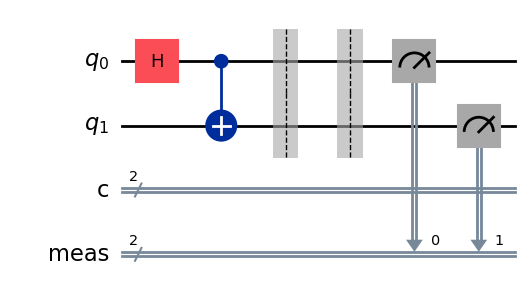

In [73]:
#Visualize the circuit
circuit.draw('mpl')

In [74]:
# convert the generated OpenQASM program to a QubiC progpram
qubic_circuit = qubicqasm.load_qasm(qasm3.dumps(circuit), qubitcfg,options={'barrier': 'none',})
pprint.pprint(qubic_circuit)

[{'name': 'declare', 'scope': None, 'var': 'c_0'},
 {'name': 'declare', 'scope': None, 'var': 'c_1'},
 {'name': 'declare', 'scope': {'Q0'}, 'var': 'meas_0'},
 {'name': 'declare', 'scope': {'Q1'}, 'var': 'meas_1'},
 {'name': 'delay', 't': 0.0005},
 {'name': 'barrier'},
 {'name': 'Y-90', 'qubit': ['Q0']},
 {'name': 'virtual_z', 'phase': 3.141592653589793, 'qubit': ['Q0']},
 {'name': 'CNOT', 'qubit': ['Q0', 'Q1']},
 {'name': 'read', 'qubit': 'Q0'},
 {'name': 'read', 'qubit': 'Q1'}]


### Qubit naming

In [75]:
# write a custom qubit mapping class
class MyQubitMap(qubicqasm.QASMQubitMap):    # alternatively, use the QubitMap abstract base class
    def get_hardware_qubit(self, qubit_reg: str, index: int):
        # basic working example, provide a dict
        mapdict={0:2,1:1}
        return super().get_hardware_qubit(qubit_reg, mapdict[index])

qubic_circuit = qubicqasm.load_qasm(qasm3.dumps(circuit), qubitcfg, qubit_map=MyQubitMap())
pprint.pprint(qubic_circuit)

[{'name': 'declare', 'scope': None, 'var': 'c_0'},
 {'name': 'declare', 'scope': None, 'var': 'c_1'},
 {'name': 'declare', 'scope': {'Q2'}, 'var': 'meas_0'},
 {'name': 'declare', 'scope': {'Q1'}, 'var': 'meas_1'},
 {'name': 'delay', 't': 0.0005},
 {'name': 'barrier'},
 {'name': 'Y-90', 'qubit': ['Q2']},
 {'name': 'virtual_z', 'phase': 3.141592653589793, 'qubit': ['Q2']},
 {'name': 'CNOT', 'qubit': ['Q2', 'Q1']},
 {'name': 'read', 'qubit': 'Q2'},
 {'name': 'read', 'qubit': 'Q1'}]


# Control flow

## Variables

### `declare` Instruction

```json
{'name': 'declare', 'var': <var_name>, 'scope': <list_of_qubits_or_channels>, 'type': <'phase' or 'amp' or 'int'>}
```
Declares a variable `var_name`. The `scope` is a list of qubits or channels that might reference the variable; for example if the variable was a loop index over qubit drive operations on Q1 and Q0, you could set `scope: ['Q0', 'Q1']` or `scope: ['Q0.qdrv', 'Q1.qdrv']`. `type` is optional and defaults to `'int'`, which is used for general purpose operations. `'phase'` and `'amp'` are types used for register-based pulse parameterization.

### `set_var` Instruction

```json
{'name': 'set_var', 'value': <value>, 'var': <var_name>}
```
This instruction simply sets the value of `var_name` to `value`

### `alu_op` Instruction

```json
{'name': 'alu', 'op': 'add' or 'sub' or 'le' or 'ge' or 'eq', 'lhs': var_name or value, 'rhs': var_name, 'out': output reg}
```

Performs a binary operation and stores it in a variable. The inputs to the operation are given by `lhs` and `rhs`. `lhs` can be an immediate value or register, and `rhs` must be a variable. Result is stored in `out` (can be the same as `lhs` and/or `rhs`).



## Branch

### `branch_var` Instruction

Same behavior as `branch_fproc`, except a variable is used in place of a measurement result.

```json
{'name': 'branch_var', 'alu_cond': <'le' or 'ge' or 'eq'>, 'cond_lhs': <var or ival>,
 'cond_rhs': <var>, 'scope': <list_of_qubits_or_channels> 'true': [instruction_list], 'false': [instruction_list]}
```



### Fast reset

In [76]:
circuit = [
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'X90', 'qubit': 'Q0'},
    {'name': 'read', 'qubit': 'Q0'}, #use a read gate, which includes an rdrv pulse followed by an rdlo pulse
    {'name': 'branch_fproc', 'alu_cond': 'eq', 'cond_lhs': 1, 'func_id': 'Q0.meas', 'scope': ['Q0'],
     'true': [
         {'name': 'X90', 'qubit':'Q0'},
         {'name': 'X90', 'qubit':'Q0'}
         ],
     'false': []},
    {'name': 'read', 'qubit': 'Q0'}]


In [77]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)

In [78]:
#compiled_prog.program

FPROC Updated at Time 528 with a measurement of 1 in qubit 0. The values are: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 1130 with a measurement of 0 in qubit 0. The values are: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


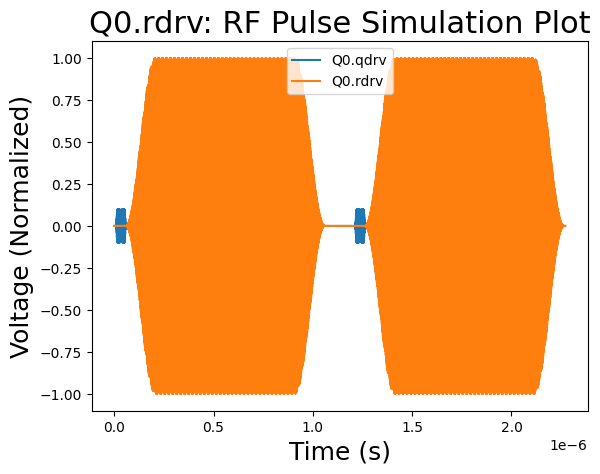

In [79]:
# run the program, and check the acc result
em.load_program(asm_prog)
result = em.execute(tags=['FPROC'], toggle_qubits=True, toggle_resonator=True)
result.graph_multiple_channels(['Q0.qdrv', 'Q0.rdrv'])

### Teleportation

In [80]:
# teleportation circuit example

q = qiskit.QuantumRegister(3)
m = qiskit.ClassicalRegister(3)

#Circuit with 3 qubits
circuit = qiskit.QuantumCircuit(q, m)

#State preparation
circuit.u(0, 1, 2, q[0])

#Shared Entaglement between qubit 1 and 2
circuit.h(q[1])
circuit.cx(q[1], q[2])

#Change of basis
circuit.cx(q[0], q[1])
circuit.h(q[0])

for i in [1,0]:
    circuit.measure(q[i], m[i])

with circuit.if_test((m[1], 1)):
    circuit.x(q[2])
with circuit.if_test((m[0], 1)):
    circuit.z(q[2])

circuit.measure(q[2], m[2])

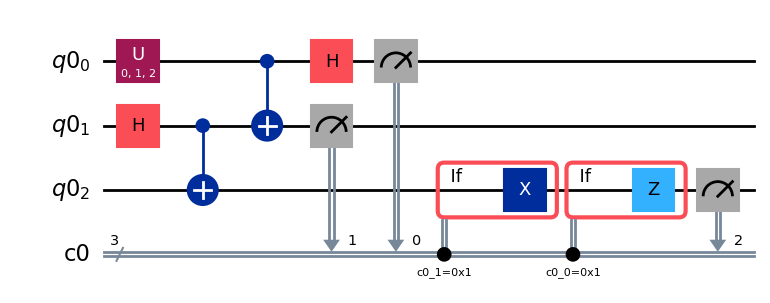

In [81]:
# display the circuit; note that the classical register as drawn is indexed
circuit.draw(output='mpl')

In [82]:
# write a custom qubit mapping class
class MyQubitMap(qubicqasm.QASMQubitMap):    # alternatively, use the QubitMap abstract base class
    def get_hardware_qubit(self, qubit_reg: str, index: int):
        # basic working example, provide a dict
        #mapdict={0:2,1:1,2:3}
        mapdict={0:3,1:2,2:1}
        return super().get_hardware_qubit(qubit_reg, mapdict[index])

qubic_circuit = qubicqasm.load_qasm(qasm3.dumps(circuit), qubitcfg, qubit_map=MyQubitMap())
pprint.pprint(qubic_circuit)

[{'dtype': 'phase', 'name': 'declare', 'scope': ['Q1'], 'var': '_bind_phaseQ1'},
 {'freq': 'Q1.freq', 'name': 'bind_phase', 'var': '_bind_phaseQ1'},
 {'name': 'declare', 'scope': {'Q3'}, 'var': 'c0_0'},
 {'name': 'declare', 'scope': {'Q2'}, 'var': 'c0_1'},
 {'name': 'declare', 'scope': {'Q1'}, 'var': 'c0_2'},
 {'name': 'delay', 't': 0.0005},
 {'name': 'barrier'},
 {'name': 'virtual_z', 'phase': -1.1415926535897931, 'qubit': ['Q3']},
 {'name': 'X90', 'qubit': ['Q3']},
 {'name': 'virtual_z', 'phase': 3.141592653589793, 'qubit': ['Q3']},
 {'name': 'X90', 'qubit': ['Q3']},
 {'name': 'virtual_z', 'phase': 1.0, 'qubit': ['Q3']},
 {'name': 'Y-90', 'qubit': ['Q2']},
 {'name': 'virtual_z', 'phase': 3.141592653589793, 'qubit': ['Q2']},
 {'name': 'CNOT', 'qubit': ['Q2', 'Q1']},
 {'name': 'CNOT', 'qubit': ['Q3', 'Q2']},
 {'name': 'Y-90', 'qubit': ['Q3']},
 {'name': 'virtual_z', 'phase': 3.141592653589793, 'qubit': ['Q3']},
 {'name': 'read', 'qubit': 'Q2'},
 {'name': 'read', 'qubit': 'Q3'},
 {'alu_

## Loop

### `loop` Instruction

The loop instruction can be used to repeat pulse sequences in hardware, with minimal latency:

```json
{'name': 'loop', 'cond_lhs': <reg or ival>, 'alu_cond': <'ge', 'le', 'eq'>, 'cond_rhs': var_name, 'scope': <list_of_qubits>, 'body': [instruction_list]}
```
This instruction will execute the instruction list in `'body'` while the condition specified in the loop instruction (`cond_lhs <alu_cond> cond_rhs)` evaluates to true. To use loops effectively, we also introduce instructions that declare and operate on **variables**:

### Repeat drive pulse

In [83]:
circuit = [
    {'name': 'declare', 'var': 'loop_ind', 'scope': ['Q0']},
    {'name': 'set_var', 'value': 0, 'var': 'loop_ind'},
#    {'name': 'delay', 't': 10.e-9},
    {'name': 'loop', 'cond_lhs': 10, 'alu_cond': 'ge', 'cond_rhs': 'loop_ind', 'scope': ['Q0'],
     'body': [
         {'name': 'X90', 'qubit': 'Q0'},
         {'name': 'alu', 'op': 'add', 'lhs': 1, 'rhs': 'loop_ind', 'out': 'loop_ind'}
     ]}]

In [84]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
#compiled_prog.program
em.load_program(asm_prog)
result = em.execute()

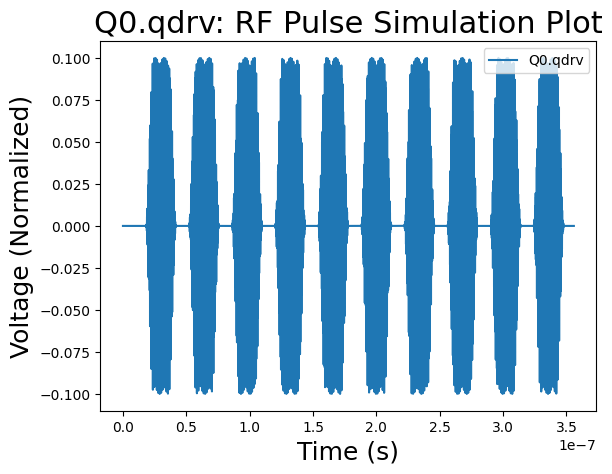

In [85]:
result.graph_channel('Q0.qdrv')

### Parameter sweep

#### Amplitude sweep

In [86]:
circuit = [
    {'name': 'declare', 'var': 'loop_ind', 'scope': ['Q0']},
    {'name': 'set_var', 'value': 0, 'var': 'loop_ind'},
    {'name': 'declare', 'var': 'amp', 'scope': ['Q0'], 'dtype': 'amp'},
    {'name': 'set_var', 'value': 0.1, 'var': 'amp'}, # pulse amplitude is parameterized by processor register
    {'name': 'loop', 'cond_lhs': 10, 'alu_cond': 'ge', 'cond_rhs': 'loop_ind', 'scope': ['Q0'],
     'body': [
            {'name': 'pulse', 'phase': 0, 'freq': 4944383311, 'amp': 'amp', 'twidth': 2.4e-08,
             'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
             'dest': 'Q0.qdrv'},
         {'name': 'alu', 'op': 'add', 'lhs': 1, 'rhs': 'loop_ind', 'out': 'loop_ind'},
         {'name': 'alu', 'op': 'add', 'lhs': 0.1, 'rhs': 'amp', 'out': 'amp'}
     ]}]

In [87]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
#compiled_prog.program

In [88]:
em.load_program(asm_prog)
result = em.execute()

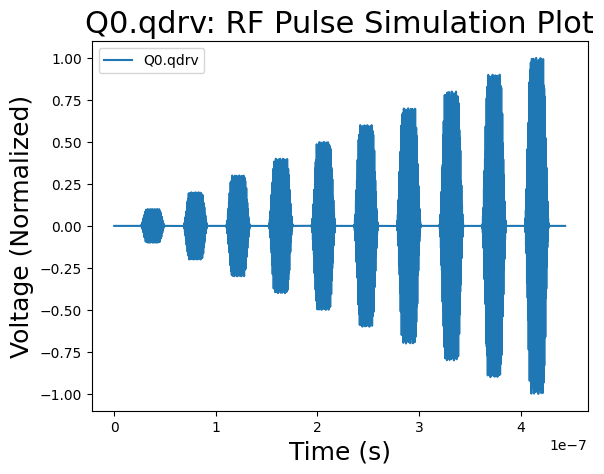

In [89]:
result.graph_channel('Q0.qdrv')

#### Frequency sweep

In [90]:
# Need to declare all frequencies at compile-time, since they are stored as pre-computed phase offsets in memory, and accessed by address
freqs = np.linspace(0, 10.e6, 11)

circuit = [{'name': 'declare_freq', 'freq': freq, 'scope': ['Q0.qdrv'], 'freq_ind': i}
           for i, freq in enumerate(freqs)]

circuit.extend([
    {'name': 'declare', 'var': 'freq_ind', 'scope': ['Q0'], 'dtype': 'int'}, # parameterize the frequency using an index
    {'name': 'set_var', 'value': 0, 'var': 'freq_ind'},
    {'name': 'loop', 'cond_lhs': len(freqs), 'alu_cond': 'ge', 'cond_rhs': 'freq_ind', 'scope': ['Q0'],
              'body': [

                    {'name': 'delay', 't': 30.e-8},

                    {'name': 'pulse', 'phase': 0, 'freq': 'freq_ind', 'amp': 0.9, 'twidth': 100e-08,
                         'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
                         'dest': 'Q0.qdrv'},

                    #{'name': 'read', 'qubit': 'Q0'},

                    {'name': 'alu', 'op': 'add', 'lhs': 1, 'rhs': 'freq_ind', 'out': 'freq_ind'},


            ]}])

In [91]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
#compiled_prog.program

In [92]:
em.load_program(asm_prog)
result = em.execute()

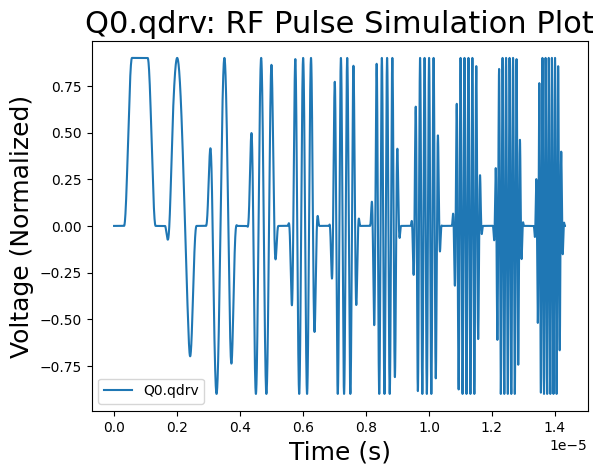

In [93]:
result.graph_channel('Q0.qdrv')

### Nested loop

In [94]:
amp_start = 0.1
amp_stop = 0.5
amp_step = 0.1

freqs = np.linspace(0, 10.e6, 5) # frequencies can be an arbitrary array,
                                          # since we're storing them in a table and accessing the address

# first, declare all frequencies
circuit = [{'name': 'declare_freq', 'freq': freq, 'scope': ['Q0.qdrv'], 'freq_ind': i}
           for i, freq in enumerate(freqs)]

# fill in the rest of the circuit
circuit.extend([
    {'name': 'declare', 'var': 'amp', 'scope': ['Q0'], 'dtype': 'amp'},

    {'name': 'declare', 'var': 'freq_ind', 'scope': ['Q0'], 'dtype': 'int'}, # frequency index is parameterized by a register
    {'name': 'set_var', 'value': 0, 'var': 'freq_ind'},

    # outer loop over frequency
    {'name': 'loop', 'cond_lhs': len(freqs), 'alu_cond': 'ge', 'cond_rhs': 'freq_ind', 'scope': ['Q0'],

     'body': [
         #{'name': 'alu', 'op': 'add', 'lhs': 2, 'rhs': 'freq_ind', 'out': 'freq_ind'},
        {'name': 'set_var', 'value': amp_start, 'var': 'amp'}, # pulse amplitude is parameterized by processor register

         # inner loop over frequency

        {'name': 'loop', 'cond_lhs': amp_stop, 'alu_cond': 'ge', 'cond_rhs': 'amp', 'scope': ['Q0'],

         'body': [

                    {'name': 'delay', 't': 100.e-9},

                    {'name': 'pulse', 'phase': 0, 'freq': 'freq_ind', 'amp': 'amp', 'twidth': 50e-08,
                         'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25}},
                         'dest': 'Q0.qdrv'},

                    #{'name': 'read', 'qubit': 'Q0'},

                    {'name': 'alu', 'op': 'add', 'lhs': amp_step, 'rhs': 'amp', 'out': 'amp'},


            ]},
          {'name': 'alu', 'op': 'add', 'lhs': 1, 'rhs': 'freq_ind', 'out': 'freq_ind'},

        ]
    }
])

In [95]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                     qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo')
)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
result = em.execute()


/usr/local/lib/python3.12/dist-packages/distproc/assembler.py:117: UserWarning: {'op': 'pulse', 'freq': 'freq_ind', 'phase': 0, 'amp': 'amp', 'env': {'env_func': 'cos_edge_square', 'paradict': {'ramp_fraction': 0.25, 'twidth': 5e-07}}, 'start_time': 63, 'dest': 'Q0.qdrv', 'label': 'loop_body_loop_0_loopctrl'} will be split into multiple instructions, which may cause timing problems
  warnings.warn(


### Loop from OpenQASM 3.0 unrolled to QubiC

In [96]:
# T1 experiment
qasm_circuits = """
OPENQASM 3.0;
include "stdgates.inc";

const duration stride = 100ns;
const int ndata = 3;

qubit[1] q;
bit c;

for int i in [0:ndata] {
    reset q[0];
    x q[0];
    delay[i * stride] q[0];
    c = measure q[0];
}"""

circuit = qubicqasm.load_qasm(qasm_circuits, qubitcfg)
pprint.pprint(circuit)

[{'dtype': 'phase', 'name': 'declare', 'scope': ['Q0'], 'var': '_bind_phaseQ0'},
 {'freq': 'Q0.freq', 'name': 'bind_phase', 'var': '_bind_phaseQ0'},
 {'name': 'declare', 'scope': {'Q0'}, 'var': 'c'},
 {'name': 'delay', 't': 0.0005},
 {'name': 'barrier'},
 {'name': 'read', 'qubit': 'Q0'},
 {'alu_cond': 'eq',
  'cond_lhs': 1,
  'false': [],
  'func_id': 'Q0.meas',
  'name': 'branch_fproc',
  'scope': ['Q0'],
  'true': [{'name': 'X90', 'qubit': ['Q0']}, {'name': 'X90', 'qubit': ['Q0']}]},
 {'name': 'virtual_z', 'phase': -1.5707963267948966, 'qubit': ['Q0']},
 {'name': 'X90', 'qubit': ['Q0']},
 {'name': 'virtual_z', 'phase': 0.0, 'qubit': ['Q0']},
 {'name': 'X90', 'qubit': ['Q0']},
 {'name': 'virtual_z', 'phase': -1.5707963267948966, 'qubit': ['Q0']},
 {'name': 'delay', 'qubit': ['Q0'], 't': 0.0},
 {'name': 'read', 'qubit': 'Q0'},
 {'name': 'read', 'qubit': 'Q0'},
 {'alu_cond': 'eq',
  'cond_lhs': 1,
  'false': [],
  'func_id': 'Q0.meas',
  'name': 'branch_fproc',
  'scope': ['Q0'],
  'tru

In [97]:
qiskit_circuit=qasm3.loads(qasm_circuits)

QASM3ImporterError: '5,0: node of type ConstantDeclaration is not supported'

### Combine Branching and Looping

#### Multiple repeated fast reset:

In [98]:
circuit = [
#    {'name': 'X90', 'qubit':'Q0'},
    {'name': 'X90', 'qubit':'Q0'},
    # initialize variables:
    {'name': 'declare', 'var': 'loop_ind', 'scope': ['Q0']},
    {'name': 'set_var', 'value': 0, 'var': 'loop_ind'},
    {'name': 'declare', 'var': 'amp', 'scope': ['Q0'], 'dtype': 'amp'},
    {'name': 'set_var', 'value': 0.1, 'var': 'amp'}, # pulse amplitude is parameterized by processor register

    {'name': 'loop', 'cond_lhs': 10, 'alu_cond': 'ge', 'cond_rhs': 'loop_ind', 'scope': ['Q0'],
     'body': [

         # read (rdlo pulse):
        {'name': 'read', 'qubit': 'Q0'},
    {'name': 'branch_fproc', 'alu_cond': 'eq', 'cond_lhs': 1, 'func_id': 'Q0.meas', 'scope': ['Q0'],
     'true': [
         {'name': 'X90', 'qubit':'Q0'},
         {'name': 'X90', 'qubit':'Q0'}
         ],
     'false': []},

         # increment loop counter
         {'name': 'alu', 'op': 'add', 'lhs': 1, 'rhs': 'loop_ind', 'out': 'loop_ind'}
     ]


     }]

In [99]:
compiled_prog = toolchain.run_compile_stage(circuit, fpga_config, qubitcfg,
                                     qubit_grouping= ('{qubit}.qdrv', '{qubit}.rdrv', '{qubit}.rdlo')
)
asm_prog = toolchain.run_assemble_stage(compiled_prog, channel_configs)
em.load_program(asm_prog)
#result = em.execute()
result = em.execute(tags=['FPROC'], toggle_qubits=True, toggle_resonator=True)


FPROC Updated at Time 516 with a measurement of 1 in qubit 0. The values are: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 1132 with a measurement of 1 in qubit 0. The values are: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 1748 with a measurement of 0 in qubit 0. The values are: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 2364 with a measurement of 1 in qubit 0. The values are: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 2980 with a measurement of 0 in qubit 0. The values are: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
FPROC Updated at Time 3596 with a measurement of 1 in qubit 0. The values are: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

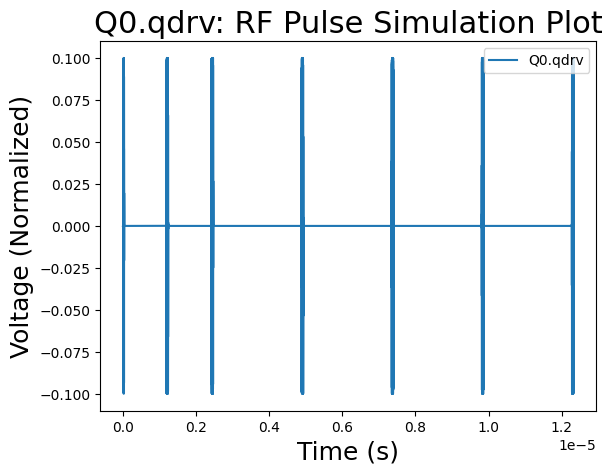

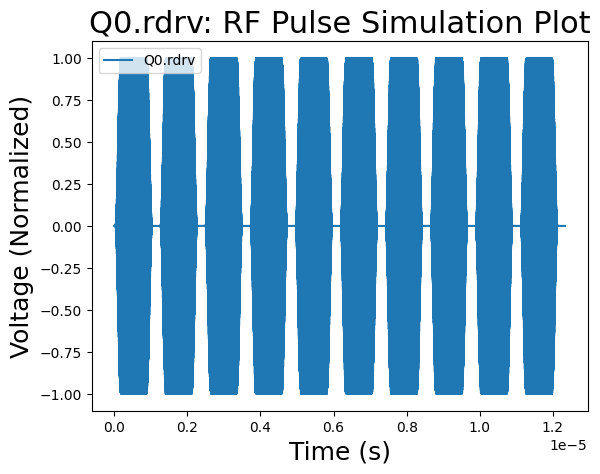

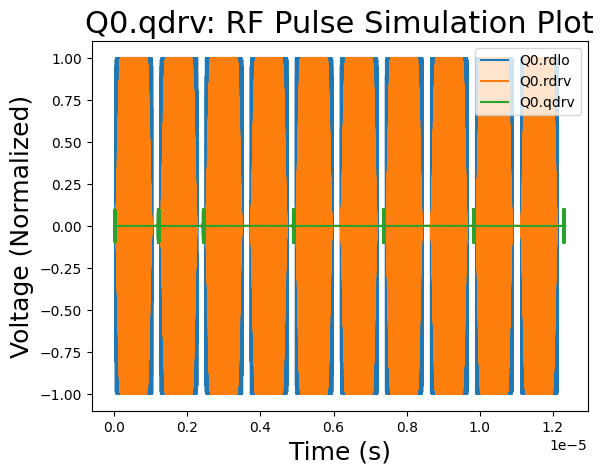

In [100]:
result.graph_channel('Q0.qdrv')
result.graph_channel('Q0.rdrv')
result.graph_multiple_channels(['Q0.rdlo', 'Q0.rdrv', 'Q0.qdrv'])